# Suturing Quality Scoring - Data Exploration & Metrics

AI-based quality control of suturing (REU project). This notebook walks the
expert annotations (Train + Val), shows the 0-10 score scale, the parameter
correlations, how much of `Overall` the five parameters explain, and
demonstrates the evaluation metrics suite (MAE, exact-match, ±1 accuracy,
Spearman, ECE, ICC, weighted Cohen's kappa).

Ticket 01 (pipeline skeleton) and ticket 02 (metrics suite) are the basis;
the real ordinal-regression model arrives in ticket 03.

In [1]:
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from suture_scoring import metrics
from suture_scoring.data import load_annotations

TRAIN_XLSX = ROOT / "Dataset/Train/Train_cohort/Train_annotations.xlsx"
VAL_XLSX = ROOT / "Dataset/Val/Validation_cohort/Validation_annotations.xlsx"

In [2]:
train = load_annotations(TRAIN_XLSX)
val = load_annotations(VAL_XLSX)
print(f"Train: {len(train)} annotated images")
print(f"Val:   {len(val)} annotated images")

df = pd.DataFrame([{"name": a.name, **a.scores} for a in train + val])
score_cols = ["Overall", "ISD", "Slack", "Position", "Angulation", "Width"]
df.head()

Train: 1010 annotated images
Val:   206 annotated images


,name,Overall,ISD,Slack,Position,Angulation,Width
0,Image_0000_04_0_0_4.png,5,7,9,7,7,7
1,Image_0001_04_0_0_4.png,2,5,7,5,5,4
2,Image_0002_04_0_0_4.png,3,6,5,7,7,7
3,Image_0003_04_0_0_4.png,5,7,6,6,7,7
4,Image_0004_04_0_0_4.png,4,7,5,6,6,7


In [3]:
df[score_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Overall,1216.0,5.423520,1.556848,1.0,4.0,6.0,6.0,10.0
ISD,1216.0,5.925164,1.213162,2.0,5.0,6.0,7.0,9.0
Slack,1216.0,6.176809,1.707641,0.0,5.0,6.0,7.0,10.0
Position,1216.0,5.773026,1.467159,1.0,5.0,6.0,7.0,9.0
Angulation,1216.0,6.391447,1.301999,1.0,6.0,7.0,7.0,9.0
Width,1216.0,6.998355,1.058766,3.0,6.0,7.0,8.0,9.0


In [4]:
for col in score_cols:
    values = df[col]
    print(f"{col:10s} range {values.min()}-{values.max()}  count of 10 = {(values == 10).sum()}")

Overall    range 1-10  count of 10 = 2
ISD        range 2-9  count of 10 = 0
Slack      range 0-10  count of 10 = 4
Position   range 1-9  count of 10 = 0
Angulation range 1-9  count of 10 = 0
Width      range 3-9  count of 10 = 0


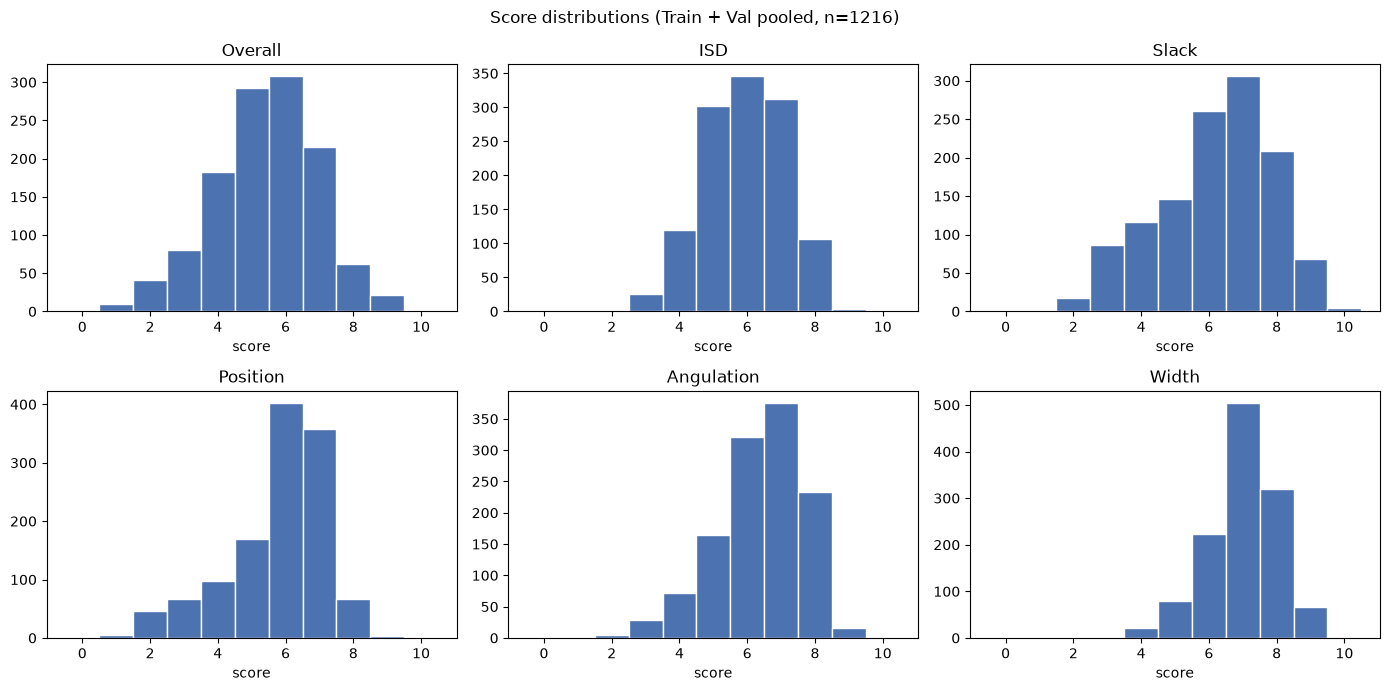

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), score_cols):
    ax.hist(df[col], bins=np.arange(-0.5, 11.5, 1), color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("score")
plt.suptitle("Score distributions (Train + Val pooled, n=1216)")
plt.tight_layout()
plt.show()

In [6]:
corr = df[score_cols].corr()
corr.round(3)

,Overall,ISD,Slack,Position,Angulation,Width
Overall,1.000,0.213,0.709,0.559,0.463,0.591
ISD,0.213,1.000,0.130,0.197,0.425,0.427
Slack,0.709,0.130,1.000,0.503,0.301,0.456
Position,0.559,0.197,0.503,1.000,0.321,0.394
Angulation,0.463,0.425,0.301,0.321,1.000,0.467
Width,0.591,0.427,0.456,0.394,0.467,1.000


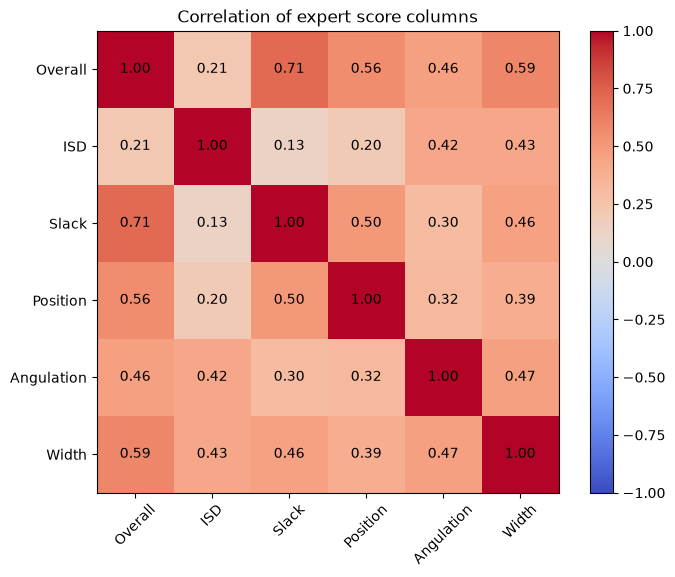

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(score_cols))); ax.set_xticklabels(score_cols, rotation=45)
ax.set_yticks(range(len(score_cols))); ax.set_yticklabels(score_cols)
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im)
plt.title("Correlation of expert score columns")
plt.show()

In [8]:
# How much of Overall do the five parameters explain? (basis of ADR-0001)
y = df["Overall"].to_numpy(dtype=float)
X = df[["ISD", "Slack", "Position", "Angulation", "Width"]].to_numpy(dtype=float)
A = np.column_stack([np.ones(len(X)), X])
beta, *_ = np.linalg.lstsq(A, y, rcond=None)
pred = A @ beta
r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"R^2 (Overall ~ ISD + Slack + Position + Angulation + Width) = {r2:.3f}")
print("coefficients:", dict(zip(["intercept", "ISD", "Slack", "Position", "Angulation", "Width"], np.round(beta, 3))))

R^2 (Overall ~ ISD + Slack + Position + Angulation + Width) = 0.645
coefficients: {'intercept': np.float64(-1.748), 'ISD': np.float64(-0.085), 'Slack': np.float64(0.414), 'Position': np.float64(0.198), 'Angulation': np.float64(0.208), 'Width': np.float64(0.377)}


In [9]:
# Dev metrics on synthetic predicted-vs-actual data (0-10 ordinal scale)
true = np.array([5, 6, 7, 8, 9, 10, 4, 3, 2, 1, 5, 6])
pred = np.array([5, 7, 6, 9, 8, 10, 4, 3, 3, 1, 6, 5])
print("MAE:              ", round(metrics.mae(true, pred), 4))
print("Exact match:      ", round(metrics.exact_match_accuracy(true, pred), 4))
print("Within +/-1:      ", round(metrics.within_tolerance_accuracy(true, pred, 1), 4))
print("Spearman:         ", round(metrics.spearman(true, pred), 4))

conf = np.array([0.95] * 6 + [0.35] * 6)
correct = (true == pred).astype(float)
print("ECE (calibration):", round(metrics.ece(conf, correct, n_bins=5), 4))

MAE:               0.5833
Exact match:       0.4167
Within +/-1:       1.0
Spearman:          0.9471
ECE (calibration): 0.3833


In [10]:
# Validation metric: ICC(2,1) on the published Shrout & Fleiss (1979) example
shrout_fleiss = np.array([
    [9, 2, 5, 8], [6, 1, 3, 2], [8, 4, 6, 8],
    [7, 1, 2, 6], [10, 5, 6, 9], [6, 2, 4, 7],
], dtype=float)
print("ICC(2,1) Shrout-Fleiss example:", round(metrics.icc(shrout_fleiss), 2), "(published: 0.29)")
identical = np.tile(np.array([[3.0], [7.0], [9.0]]), (1, 4))
print("ICC(2,1) identical raters:    ", metrics.icc(identical))

ICC(2,1) Shrout-Fleiss example: 0.29 (published: 0.29)
ICC(2,1) identical raters:     1.0


In [11]:
# Validation metric: weighted Cohen's kappa on a hand-computed fixture
y1 = [0, 0, 1, 1, 2, 2]
y2 = [0, 1, 1, 2, 2, 2]
print("Quadratic-weighted kappa:", round(metrics.weighted_cohens_kappa(y1, y2, "quadratic"), 4), "(hand-computed: 0.75)")
print("Linear-weighted kappa:   ", round(metrics.weighted_cohens_kappa(y1, y2, "linear"), 4))

Quadratic-weighted kappa: 0.75 (hand-computed: 0.75)
Linear-weighted kappa:    0.625


In [12]:
# Validation metric on the full 0-10 ordinal scale (paper usage)
a10 = np.array([5, 6, 7, 8, 9, 10, 4, 3, 2, 1, 5, 6])
b10 = np.array([5, 7, 6, 9, 8, 10, 4, 3, 3, 1, 6, 5])
print("kappa, inferred range:   ", round(metrics.weighted_cohens_kappa(a10, b10, "quadratic"), 4))
print("kappa, full 0-10 scale:  ", round(metrics.weighted_cohens_kappa(a10, b10, "quadratic", n_categories=11), 4))

kappa, inferred range:    0.9562
kappa, full 0-10 scale:   0.9562


In [13]:
# End-to-end smoke: preprocess a fixture image and score it (toy model, ticket 01)
from suture_scoring.model import ToyScorer
from suture_scoring.preprocess import preprocess_image

image = preprocess_image(ROOT / "tests/fixtures/images/Image_0000_04_0_0_4.png")
row = {"filename": "Image_0000_04_0_0_4.png", **ToyScorer().score(image)}
pd.DataFrame([row]).T

,0
filename,Image_0000_04_0_0_4.png
Overall,7.8
ISD,7.9
Slack,8.0
Position,8.1
Angulation,8.2
Width,8.3
conf_Overall,0.9
conf_ISD,0.9
conf_Slack,0.9


## Next steps

- **Ticket 03**: replace the toy scorer with the ordinal-regression CNN (multi-head, implicit geometry), trained on Train with a held-out slice for model selection; confidence comes from the ordinal distribution spread.
- **Ticket 04**: the hybrid `Overall` aggregation (parameters + learned residual, ADR-0001).
- **Ticket 05/06**: score all three cohorts, validate against expert labels (ICC, weighted kappa per trainee level), and generate the paper artifacts.

Notebooks will follow each stage so results stay visible in Jupyter fashion.